In [1]:
import pandas as pd
import numpy as np

Сделаем EDA

In [2]:
df = pd.read_csv('mushrooms.csv')

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

В данных 22 признака(все категориальные) и нет пропусков

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
for col in df.columns:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Значения: {df[col].unique().tolist()[:10]}")


class:
  Уникальных значений: 2
  Значения: ['p', 'e']

cap-shape:
  Уникальных значений: 6
  Значения: ['x', 'b', 's', 'f', 'k', 'c']

cap-surface:
  Уникальных значений: 4
  Значения: ['s', 'y', 'f', 'g']

cap-color:
  Уникальных значений: 10
  Значения: ['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']

bruises:
  Уникальных значений: 2
  Значения: ['t', 'f']

odor:
  Уникальных значений: 9
  Значения: ['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']

gill-attachment:
  Уникальных значений: 2
  Значения: ['f', 'a']

gill-spacing:
  Уникальных значений: 2
  Значения: ['c', 'w']

gill-size:
  Уникальных значений: 2
  Значения: ['n', 'b']

gill-color:
  Уникальных значений: 12
  Значения: ['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r']

stalk-shape:
  Уникальных значений: 2
  Значения: ['e', 't']

stalk-root:
  Уникальных значений: 5
  Значения: ['e', 'c', 'b', 'r', '?']

stalk-surface-above-ring:
  Уникальных значений: 4
  Значения: ['s', 'f', 'k', 'y']

stalk-surface-below-ring:
  

Видим, что у veil-type всего одно уникальное значение, значит оно никак не повлияет на модель, нужно сразу исключать. Подтверждаем гипотезу 6

In [7]:
df.drop(columns=['veil-type'], inplace=True)

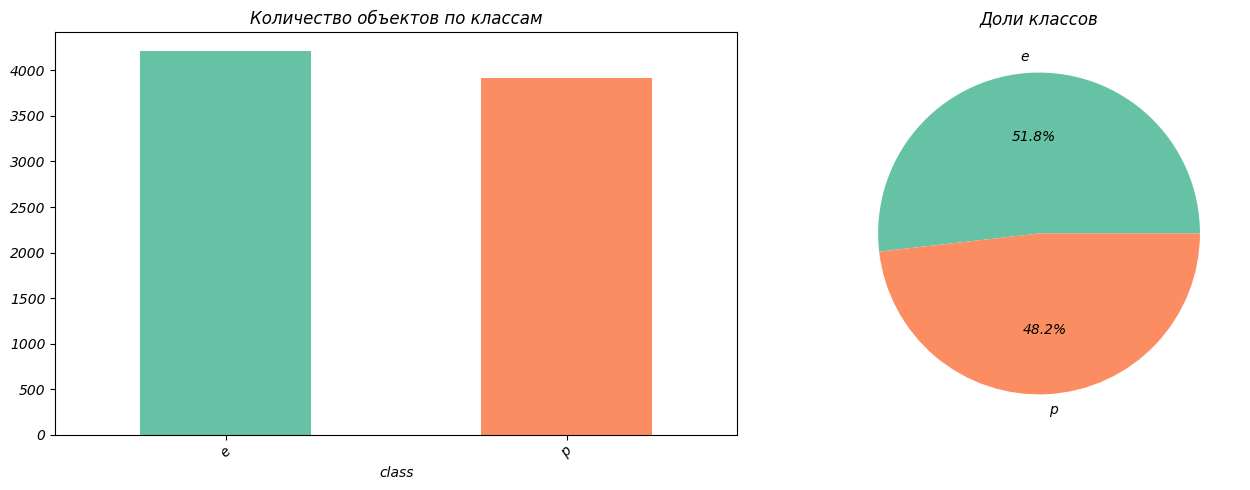

In [8]:
target_col = 'class'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Классы сбалансированы 

Разделим на train/test

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Для категориальных признаков нельзя просто посчитать корреляцию Пирсона, точнее посчитать-то можно после label encoder или one hot encoder, но это не даст правильной полноценной картины. Аналогом выступает коэффициент V Крамера, считаем

In [10]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1) * (r-1))/(n-1))
    rcorr = r - ((r-1) ** 2)/(n-1)
    kcorr = k - ((k-1) ** 2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_results = {}
for col in X_train.columns:
    cramers_results[col] = cramers_v(X_train[col], y_train)

sorted_cramers = sorted(cramers_results.items(), key=lambda x: x[1], reverse=True)

print("Топ-10 признаков по коэффициенту V Крамера:")
for col, cv in sorted_cramers[:10]:
    print(f"{col}: {cv:.3f}")

Топ-10 признаков по коэффициенту V Крамера:
odor: 0.970
spore-print-color: 0.755
gill-color: 0.679
ring-type: 0.604
stalk-surface-above-ring: 0.591
stalk-surface-below-ring: 0.576
gill-size: 0.532
stalk-color-above-ring: 0.526
stalk-color-below-ring: 0.517
bruises: 0.502


Видим, что топ 3 по важности odor, spore-print-color, gill-color. Совпадает с тем топом, который был напрогнозирован в гипотезе 2

Визуализируем

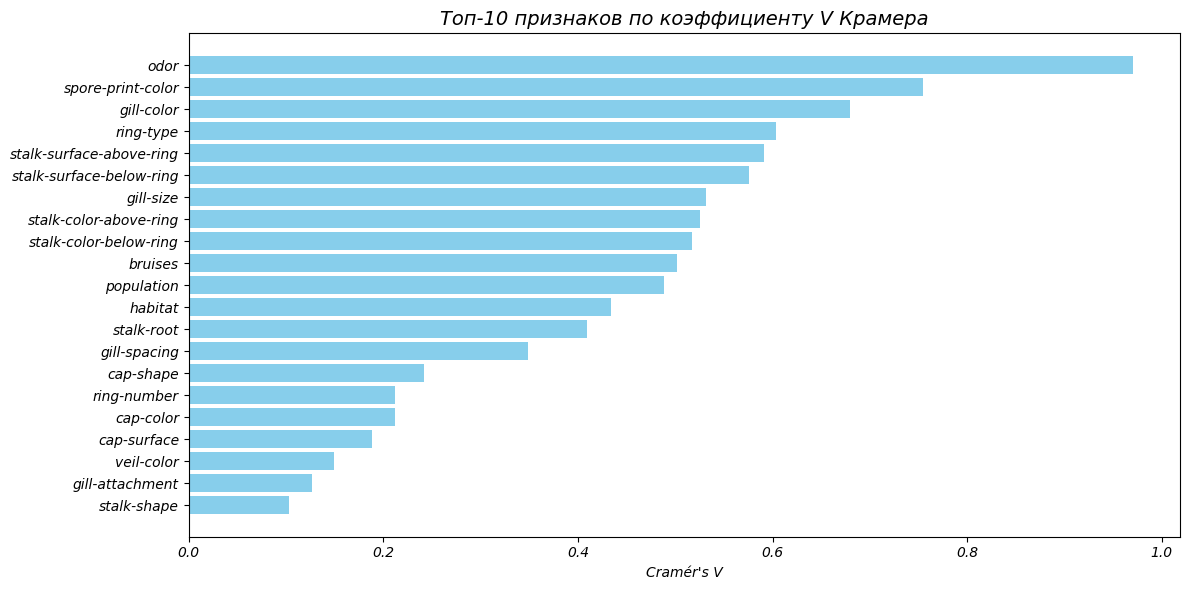

In [11]:
plt.figure(figsize=(12, 6))
features, values = zip(*sorted_cramers)
plt.barh(features, values, color='skyblue')
plt.xlabel('Cramér\'s V')
plt.title('Топ-10 признаков по коэффициенту V Крамера', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Изучим, как самый важный признак влияет на класс

<Figure size 1200x600 with 0 Axes>

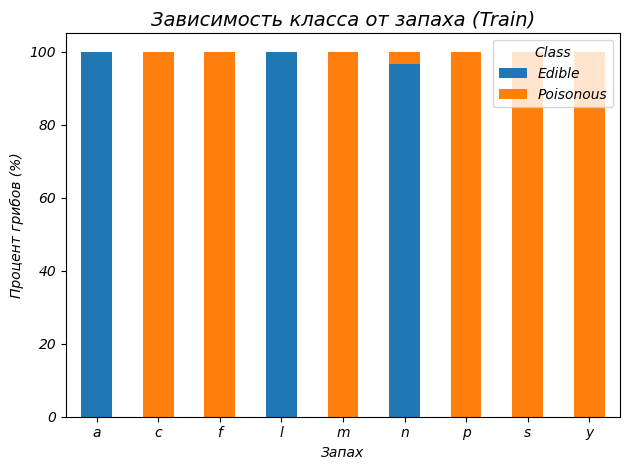

Зависимость класса от запаха (Train):
f: 0.0% съедобных, 100.0% ядовитых
n: 96.6% съедобных, 3.4% ядовитых
s: 0.0% съедобных, 100.0% ядовитых
l: 100.0% съедобных, 0.0% ядовитых
y: 0.0% съедобных, 100.0% ядовитых
a: 100.0% съедобных, 0.0% ядовитых
c: 0.0% съедобных, 100.0% ядовитых
p: 0.0% съедобных, 100.0% ядовитых
m: 0.0% съедобных, 100.0% ядовитых


In [12]:
odor_class = pd.crosstab(X_train['odor'], y_train, normalize='index') * 100

plt.figure(figsize=(12, 6))
odor_class.plot(kind='bar', stacked=True)
plt.title('Зависимость класса от запаха (Train)', fontsize=14)
plt.xlabel('Запах')
plt.ylabel('Процент грибов (%)')
plt.legend(title='Class', labels=['Edible', 'Poisonous'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


print("Зависимость класса от запаха (Train):")
for odor in X_train['odor'].unique():
    edible_pct = (y_train[X_train['odor'] == odor] == 'e').mean() * 100
    poisonous_pct = 100 - edible_pct
    print(f"{odor}: {edible_pct:.1f}% съедобных, {poisonous_pct:.1f}% ядовитых")

Видим, что есть идеальные разделители. l, a значит точно съедобен, f, s, y, c, p, m значит точно ядовит. Единственный условно сложный случай это n, где необходимо использовать другие признаки

Проверим первую гипотезу, для этого сначала переведем признак odor в численные значения с помощью label encoder, так же поступим и с целевой переменной

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

X_train_odor = X_train[['odor']].copy()
X_test_odor = X_test[['odor']].copy()

le_odor = LabelEncoder()
X_train_odor_encoded = le_odor.fit_transform(X_train_odor['odor'])
X_test_odor_encoded = le_odor.transform(X_test_odor['odor'])

X_train_odor_df = pd.DataFrame(X_train_odor_encoded, columns=['odor'])
X_test_odor_df = pd.DataFrame(X_test_odor_encoded, columns=['odor'])

le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)

Ставим максимальную глубину 3 и обучаем дерево

In [14]:
dt_odor = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_odor.fit(X_train_odor_df, y_train_encoded)

y_train_pred_odor = dt_odor.predict(X_train_odor_df)
y_test_pred_odor = dt_odor.predict(X_test_odor_df)

train_acc_odor = accuracy_score(y_train_encoded, y_train_pred_odor)
test_acc_odor = accuracy_score(y_test_encoded, y_test_pred_odor)

print(f"Train Accuracy: {train_acc_odor:.4f} ({train_acc_odor*100:.2f}%)")
print(f"Test Accuracy:  {test_acc_odor:.4f} ({test_acc_odor*100:.2f}%)")
print(f"Разница:        {(train_acc_odor - test_acc_odor):.4f}")


print(classification_report(y_test_encoded, y_test_pred_odor, 
                            target_names=['edible', 'poisonous']))

cm = confusion_matrix(y_test_encoded, y_test_pred_odor)
print("\nМатрица ошибок (Test):")
print(pd.DataFrame(cm, index=['edible', 'poisonous'], columns=['pred_edible', 'pred_poisonous']))

Train Accuracy: 0.9809 (98.09%)
Test Accuracy:  0.9803 (98.03%)
Разница:        0.0006
              precision    recall  f1-score   support

      edible       0.96      1.00      0.98       842
   poisonous       1.00      0.96      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625


Матрица ошибок (Test):
           pred_edible  pred_poisonous
edible             842               0
poisonous           32             751


Очень хороший результат, на съедобных грибах в принципе не ошибаемся, а ведь это всего лишь неглубокое дерево на одном признаке(закроем пока глаза на то, что мы потенциально 32 раза отравимся)

В итоге первая гипотеза подтвердилась, при этом третья гипотеза так же получила подтверждение, различие между Accuracy и F1 macro меньше 1%

Попробуем теперь использовать топ 3 признака

In [15]:
top3_features = ['odor', 'spore-print-color', 'gill-color']
X_train_top3 = X_train[top3_features].copy()
X_test_top3 = X_test[top3_features].copy()

X_train_top3_encoded = pd.DataFrame()
X_test_top3_encoded = pd.DataFrame()

for col in top3_features:
    le = LabelEncoder()
    X_train_top3_encoded[col] = le.fit_transform(X_train_top3[col])
    X_test_top3_encoded[col] = le.transform(X_test_top3[col])

In [16]:
dt_top3 = DecisionTreeClassifier(random_state=42)
dt_top3.fit(X_train_top3_encoded, y_train_encoded)

y_train_pred_top3 = dt_top3.predict(X_train_top3_encoded)
y_test_pred_top3 = dt_top3.predict(X_test_top3_encoded)

train_acc_top3 = accuracy_score(y_train_encoded, y_train_pred_top3)
test_acc_top3 = accuracy_score(y_test_encoded, y_test_pred_top3)


print(f"Train Accuracy: {train_acc_top3:.4f} ({train_acc_top3*100:.2f}%)")
print(f"Test Accuracy:  {test_acc_top3:.4f} ({test_acc_top3*100:.2f}%)")
print(f"Разница:        {(train_acc_top3 - test_acc_top3):.4f}")

print(classification_report(y_test_encoded, y_test_pred_top3, 
                            target_names=['edible', 'poisonous']))

cm_top3 = confusion_matrix(y_test_encoded, y_test_pred_top3)
print("\nМатрица ошибок (Test):")
print(pd.DataFrame(cm_top3, index=['edible', 'poisonous'], columns=['pred_edible', 'pred_poisonous']))

Train Accuracy: 0.9949 (99.49%)
Test Accuracy:  0.9932 (99.32%)
Разница:        0.0017
              precision    recall  f1-score   support

      edible       0.99      1.00      0.99       842
   poisonous       1.00      0.99      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625


Матрица ошибок (Test):
           pred_edible  pred_poisonous
edible             842               0
poisonous           11             772


Результат стал еще лучше, теперь травимся всего 11 раз, на съедобных не ошибаемся

Проверим гипотезу 5, будем использовать все признаки

кодируем признаки с помощью one hot

In [17]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

Задаем дерево без ограничений и обучаем его

In [18]:
dt_overfit = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    random_state=42
)

dt_overfit.fit(X_train_ohe, y_train_encoded)

y_train_pred_overfit = dt_overfit.predict(X_train_ohe)
y_test_pred_overfit = dt_overfit.predict(X_test_ohe)

train_acc_overfit = accuracy_score(y_train_encoded, y_train_pred_overfit)
test_acc_overfit = accuracy_score(y_test_encoded, y_test_pred_overfit)

print(f"Train Accuracy: {train_acc_overfit:.4f} ({train_acc_overfit*100:.2f}%)")
print(f"Test Accuracy:  {test_acc_overfit:.4f} ({test_acc_overfit*100:.2f}%)")
print(f"Разница:        {(train_acc_overfit - test_acc_overfit):.4f}")

Train Accuracy: 1.0000 (100.00%)
Test Accuracy:  1.0000 (100.00%)
Разница:        0.0000


Кажется, датасет достался такой, что даже дерево не переобучается, на тесте accuracy = 1, так же, как и на train

Получается, что гипотеза 5 не подтвердилась, но это из-за слишком правильного датасета. На реальных данных с шумом и неидеальной разметкой такой результат невозможен

Проверим с помощью кросс валидации, не повезло ли нам с тестом

In [19]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ('dt', DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    random_state=42
))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    return_train_score=True,
    return_estimator=True,
    verbose=1
)

for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    train_mean = cv_results[f'train_{metric}'].mean()
    train_std = cv_results[f'train_{metric}'].std()
    test_mean = cv_results[f'test_{metric}'].mean()
    test_std = cv_results[f'test_{metric}'].std()
    
    print(f"\n{metric.upper()}:")
    print(f"  Train: {train_mean:.6f} (±{train_std:.6f})")
    print(f"  Test:  {test_mean:.6f} (±{test_std:.6f})")
    print(f"  Разница: {train_mean - test_mean:.6f}")


ACCURACY:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000

F1_MACRO:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000

PRECISION_MACRO:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000

RECALL_MACRO:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


Получилось, что задача идеально разрешима

Теперь проверим 4 гипотезу, обучим логистическую регрессию, не забудем про скалирование данных

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipeline_lr_ohe = Pipeline([
    ('ohe', OneHotEncoder(sparse_output=False)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=100,
        random_state=42
    ))
])

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_lr = cross_validate(
    pipeline_lr_ohe,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    return_train_score=True,
    verbose=1
)

for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    train_mean = cv_results_lr[f'train_{metric}'].mean()
    train_std = cv_results_lr[f'train_{metric}'].std()
    test_mean = cv_results_lr[f'test_{metric}'].mean()
    test_std = cv_results_lr[f'test_{metric}'].std()
    
    print(f"\n{metric.upper()}:")
    print(f"  Train: {train_mean:.6f} (±{train_std:.6f})")
    print(f"  Test:  {test_mean:.6f} (±{test_std:.6f})")
    print(f"  Разница: {train_mean - test_mean:.6f}")


ACCURACY:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000

F1_MACRO:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000

PRECISION_MACRO:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000

RECALL_MACRO:
  Train: 1.000000 (±0.000000)
  Test:  1.000000 (±0.000000)
  Разница: 0.000000


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


Данные получились линейно разделимы, значит гипотеза 4 не подтвердилась. Логистическая регрессия дает такой же идеальный результат, как и дерево решений